In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

path_to_data = Path("../data/")
path_to_labels = path_to_data / "labels.csv"

# Load the labels as a DataFrame
df = pd.read_csv(path_to_labels)
df.head(2)

,id,breed,single_dog,multiple_dogs,dog_bounding_boxes
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull,True,False,"[[124.44112396240234, 3.506159782409668, 252.6..."
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo,True,False,"[[83.6861343383789, 33.29807662963867, 371.529..."


In [2]:
single = df.loc[df["single_dog"] == True]
n_singles = len(single)
print(
    f"One dog is visible in {n_singles} ({n_singles/ len(df) * 100:.2f}%) images."
)

One dog is visible in 8654 (84.66%) images.


In [3]:
# Count single-dog images per breed, sorted alphabetically
breed_counts = single["breed"].value_counts().sort_index()
print(breed_counts.to_string())

breed
affenpinscher                      70
afghan_hound                       86
african_hunting_dog                51
airedale                           93
american_staffordshire_terrier     69
appenzeller                        70
australian_terrier                 94
basenji                            86
basset                             67
beagle                             97
bedlington_terrier                 73
bernese_mountain_dog              103
black-and-tan_coonhound            69
blenheim_spaniel                   82
bloodhound                         77
bluetick                           77
border_collie                      64
border_terrier                     82
borzoi                             60
boston_bull                        72
bouvier_des_flandres               76
boxer                              72
brabancon_griffon                  64
briard                             53
brittany_spaniel                   68
bull_mastiff                       63
cairn 

In [4]:
# Check if any breed is entirely absent from single-dog images
all_breeds = set(df["breed"].unique())
single_breeds = set(single["breed"].unique())
missing = all_breeds - single_breeds
print(f"Breeds with no single_dog=True rows: {missing if missing else 'None'}")

Breeds with no single_dog=True rows: None


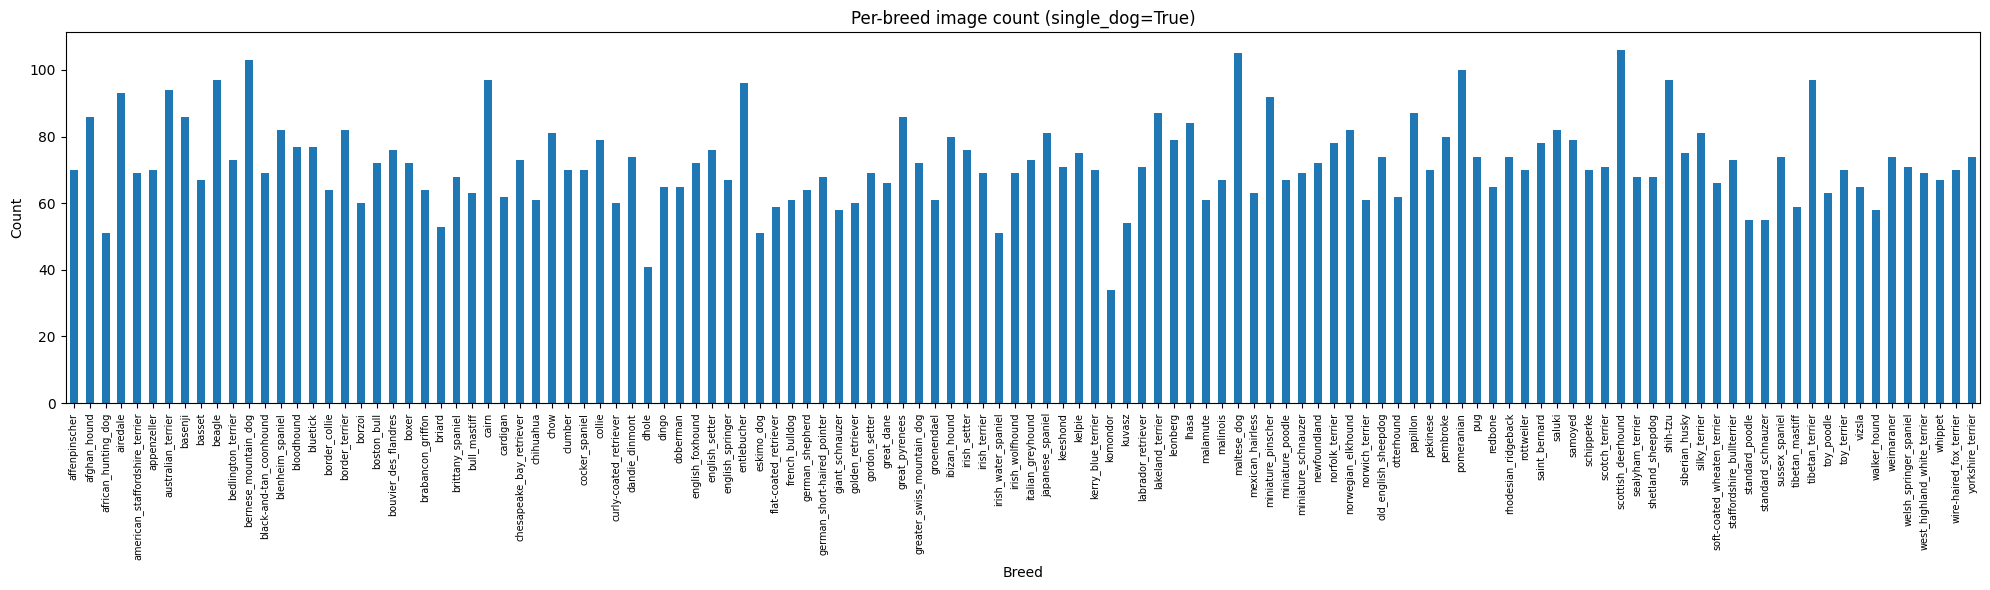

In [5]:
# Bar chart of per-breed image counts for single-dog images
fig, ax = plt.subplots(figsize=(20, 6))
breed_counts.plot(kind="bar", ax=ax)
ax.set_title("Per-breed image count (single_dog=True)")
ax.set_xlabel("Breed")
ax.set_ylabel("Count")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

In [6]:
# Summary statistics: distribution spread and extreme breeds
print(breed_counts.describe())
print(f"\nLowest:  {breed_counts.idxmin()} ({breed_counts.min()})")
print(f"Highest: {breed_counts.idxmax()} ({breed_counts.max()})")

count    120.000000
mean      72.116667
std       12.524385
min       34.000000
25%       65.000000
50%       70.000000
75%       78.250000
max      106.000000
Name: count, dtype: float64

Lowest:  komondor (34)
Highest: scottish_deerhound (106)


In [7]:
# Check bounding box completeness
null_mask  = df["dog_bounding_boxes"].isna()
empty_mask = df["dog_bounding_boxes"].eq("") | df["dog_bounding_boxes"].eq("[]")
problem_mask = null_mask | empty_mask

print(f"Null values:              {null_mask.sum()}")
print(f"Empty string / '[]':      {empty_mask.sum()}")
print(f"Total missing bbox rows:  {problem_mask.sum()} / {len(df)}")
if problem_mask.any():
    print("\nSample problem rows:")
    print(df[problem_mask][["id", "breed", "single_dog", "multiple_dogs", "dog_bounding_boxes"]].head(10).to_string())

Null values:              0
Empty string / '[]':      465
Total missing bbox rows:  465 / 10222

Sample problem rows:
                                   id                breed  single_dog  multiple_dogs dog_bounding_boxes
15   00792e341f3c6eb33663e415d0715370  african_hunting_dog       False          False                 []
49   0140b05bfc2fd43f2819fab3d8566109   norwegian_elkhound       False          False                 []
50   014c2b0cd8e3b517e649cecf8543b8fe  african_hunting_dog       False          False                 []
51   0159b6457aac89f43d1c1931cdf7500b  irish_water_spaniel       False          False                 []
87   0214e2d616ec7eb7cb0d8c19a7f29e70           weimaraner       False          False                 []
172  040fef64640b89c53f161b6c5215b78b        affenpinscher       False          False                 []
194  0484a6cc686a07e1edacd0fb44b1d965        affenpinscher       False          False                 []
205  04d2dc1f2804c748b1aa71954bb45d38     

## Cropped Images Dataset

In [8]:
path_to_cropped_labels = path_to_data / "cropped_image_labels.csv"
crops = pd.read_csv(path_to_cropped_labels)
print(f"Total cropped images: {len(crops)}")
crops.head(2)

Total cropped images: 11077


,id,breed
0,4d908ad209464a41bd4770a45a77700b,boston_bull
1,b9a91bb808a24e218c4e53dc0844de90,dingo


In [9]:
crop_breed_counts = crops["breed"].value_counts().sort_index()
print(crop_breed_counts.to_string())

breed
affenpinscher                      78
afghan_hound                      131
african_hunting_dog                71
airedale                          114
american_staffordshire_terrier     79
appenzeller                        88
australian_terrier                111
basenji                           140
basset                            101
beagle                            115
bedlington_terrier                 77
bernese_mountain_dog              126
black-and-tan_coonhound            77
blenheim_spaniel                  119
bloodhound                        100
bluetick                           95
border_collie                      79
border_terrier                     98
borzoi                             86
boston_bull                       102
bouvier_des_flandres               78
boxer                              78
brabancon_griffon                  71
briard                             75
brittany_spaniel                   76
bull_mastiff                       89
cairn 

In [10]:
all_breeds = set(df["breed"].unique())
crop_breeds = set(crops["breed"].unique())
missing = all_breeds - crop_breeds
print(f"Breeds with no cropped images: {missing if missing else 'None'}")

Breeds with no cropped images: None


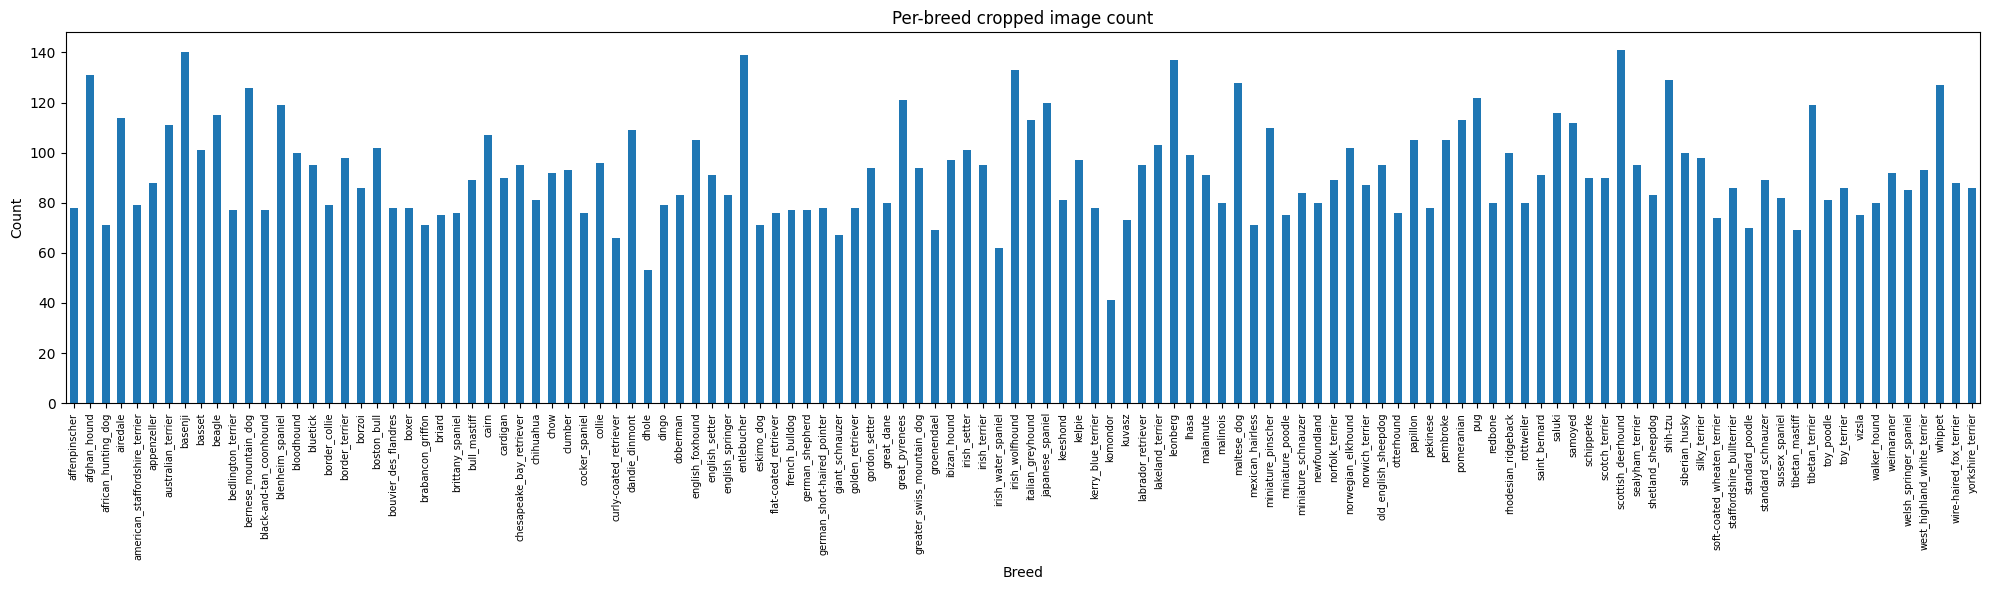

In [11]:
fig, ax = plt.subplots(figsize=(20, 6))
crop_breed_counts.plot(kind="bar", ax=ax)
ax.set_title("Per-breed cropped image count")
ax.set_xlabel("Breed")
ax.set_ylabel("Count")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

In [12]:
print(crop_breed_counts.describe())
print(f"\nLowest:  {crop_breed_counts.idxmin()} ({crop_breed_counts.min()})")
print(f"Highest: {crop_breed_counts.idxmax()} ({crop_breed_counts.max()})")

count    120.000000
mean      92.308333
std       19.134990
min       41.000000
25%       78.000000
50%       89.500000
75%      102.000000
max      141.000000
Name: count, dtype: float64

Lowest:  komondor (41)
Highest: scottish_deerhound (141)
